In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import gc
import jax
gc.collect()
jax.clear_caches()

import superstats as sup
import numpy as np

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lschumacher/.local/share/uv/python/cpython-3.13.14-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'


In [2]:
# import os
# print(os.getpid())

In [3]:
# !nvidia-smi

## Constants

In [4]:
NUM_STEPS = 480
NUM_SAMPLES = 1000

## Context

In [5]:
def generate_context(num_steps):
    conditions = [
        (0.5, 0.5),   # high difficulty, high reward
        (0.5, -0.5),  # high difficulty, low reward
        (-0.5, 0.5),  # low difficulty, high reward
        (-0.5, -0.5), # low difficulty, low reward
    ]
    num_blocks = (num_steps + 59) // 60
    conditions = (conditions * ((num_blocks + len(conditions) - 1) // len(conditions)))[:num_blocks]
    np.random.shuffle(conditions)
    difficulty = []
    reward = []
    remaining_steps = num_steps
    for difficulty_code, reward_code in conditions:
        block_steps = min(60, remaining_steps)
        difficulty.extend([difficulty_code] * block_steps)
        reward.extend([reward_code] * block_steps)
        remaining_steps -= block_steps
    return {
        "difficulty": difficulty,
        "reward": reward,
    }

In [6]:
context_simulator = sup.ContextSimulator(
    simulator=generate_context,
    is_batched=False
)

## Prior

In [7]:
formula = sup.Formula([
    "v = v_0 + b_v_1 * difficulty + b_v_2 * reward + b_v_3 * difficulty * reward",
    "a = a_0 + b_a_1 * difficulty + b_a_2 * reward + b_a_3 * difficulty * reward",
    "tau = tau_0 + b_tau_1 * difficulty + b_tau_2 * reward + b_tau_3 * difficulty * reward",
])

prior = sup.JointPrior(
    v_0=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.15),
    ),
    b_v_1=sup.Prior("normal", loc=0.0, scale=2.0),
    b_v_2=sup.Prior("normal", loc=0.0, scale=2.0),
    b_v_3=sup.Prior("normal", loc=0.0, scale=2.0),
    a_0=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.15),
    ),
    b_a_1=sup.Prior("normal", loc=0.0, scale=2.0),
    b_a_2=sup.Prior("normal", loc=0.0, scale=2.0),
    b_a_3=sup.Prior("normal", loc=0.0, scale=2.0),
    tau_0=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=0.0, scale=0.75),
        sigma=sup.Prior("halfnormal", scale=0.075),
    ),
    b_tau_1=sup.Prior("normal", loc=0.0, scale=0.5),
    b_tau_2=sup.Prior("normal", loc=0.0, scale=0.5),
    b_tau_3=sup.Prior("normal", loc=0.0, scale=0.5),
    bias=0.5,
    p_missing=sup.Prior("beta", a=1.5, b=15.0),
)

In [8]:
missing_process = sup.simulation.RandomMissingProcess(
    missing_value=-1,
)

model = sup.Model(
    prior=prior,
    simulator=sup.simulation.sample_ddm,
    formula_link_functions={
        'v': sup.LinkFunction(bounds=(0.0, 8.0)),
        'a': sup.LinkFunction(bounds=(0.0, 6.0)),
        'tau': sup.LinkFunction(bounds=(0.0, 1.0))
    }, 
    formula=formula,
    context_simulator=context_simulator,
    design_context=('difficulty', 'reward'),
    missing=missing_process,
)

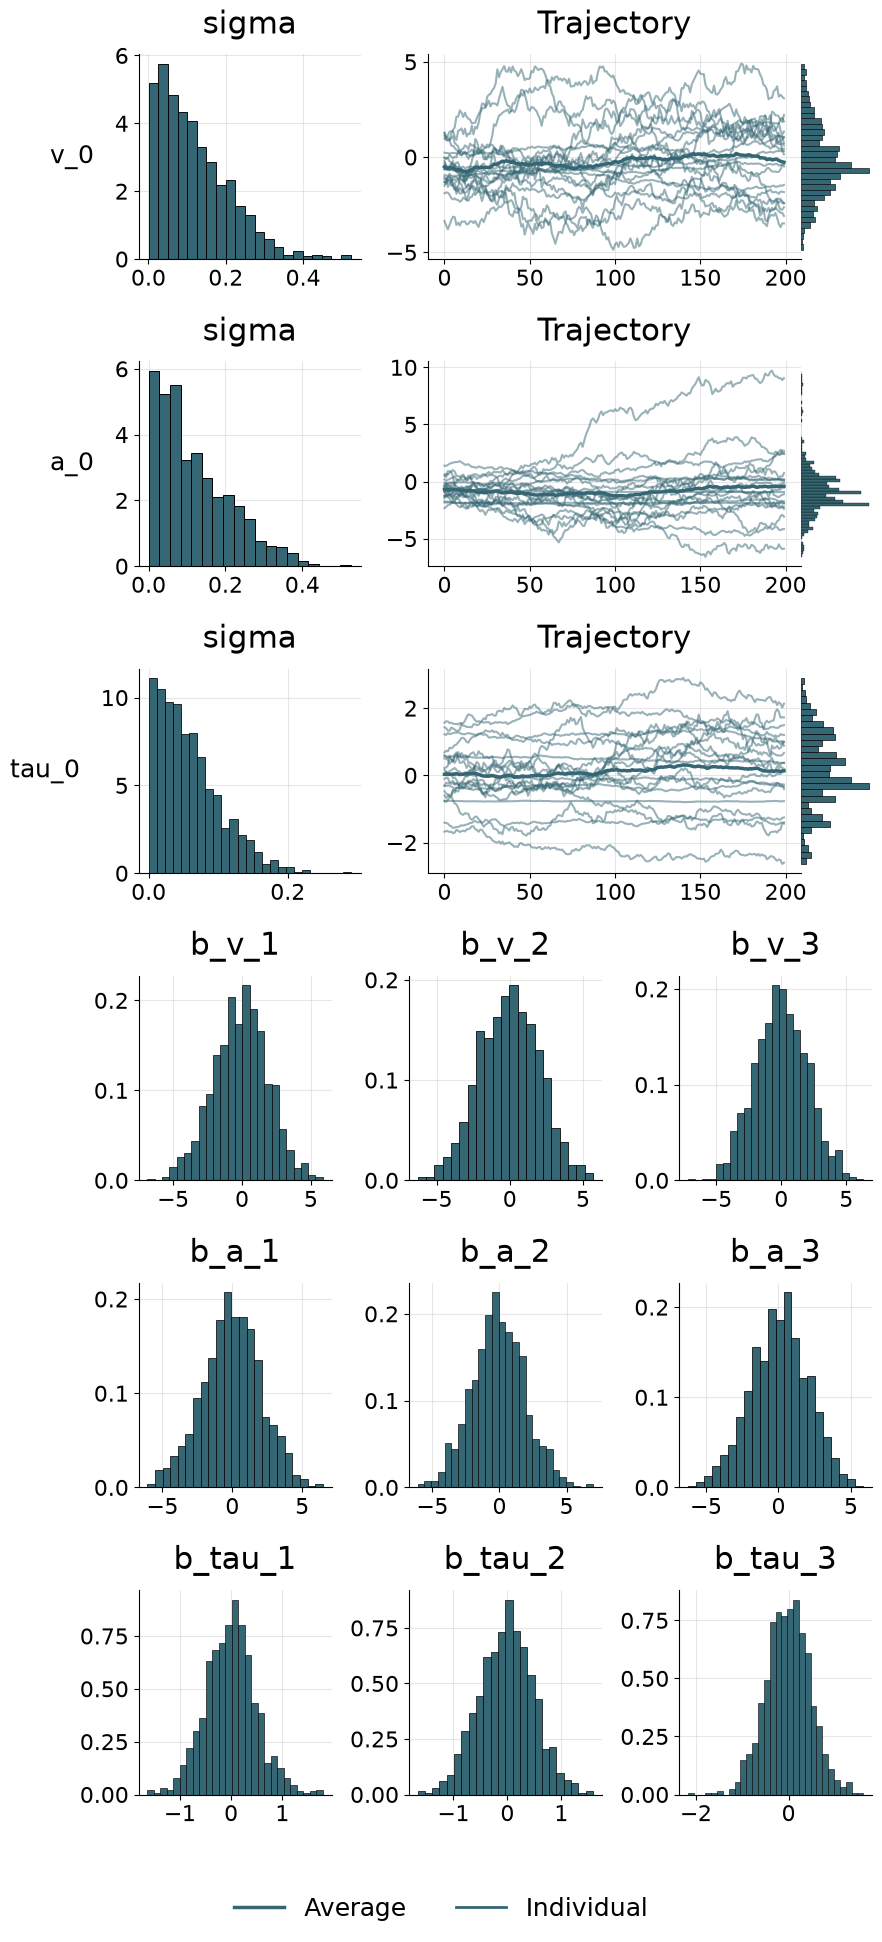

In [9]:
fig = model.plot_joint_prior()

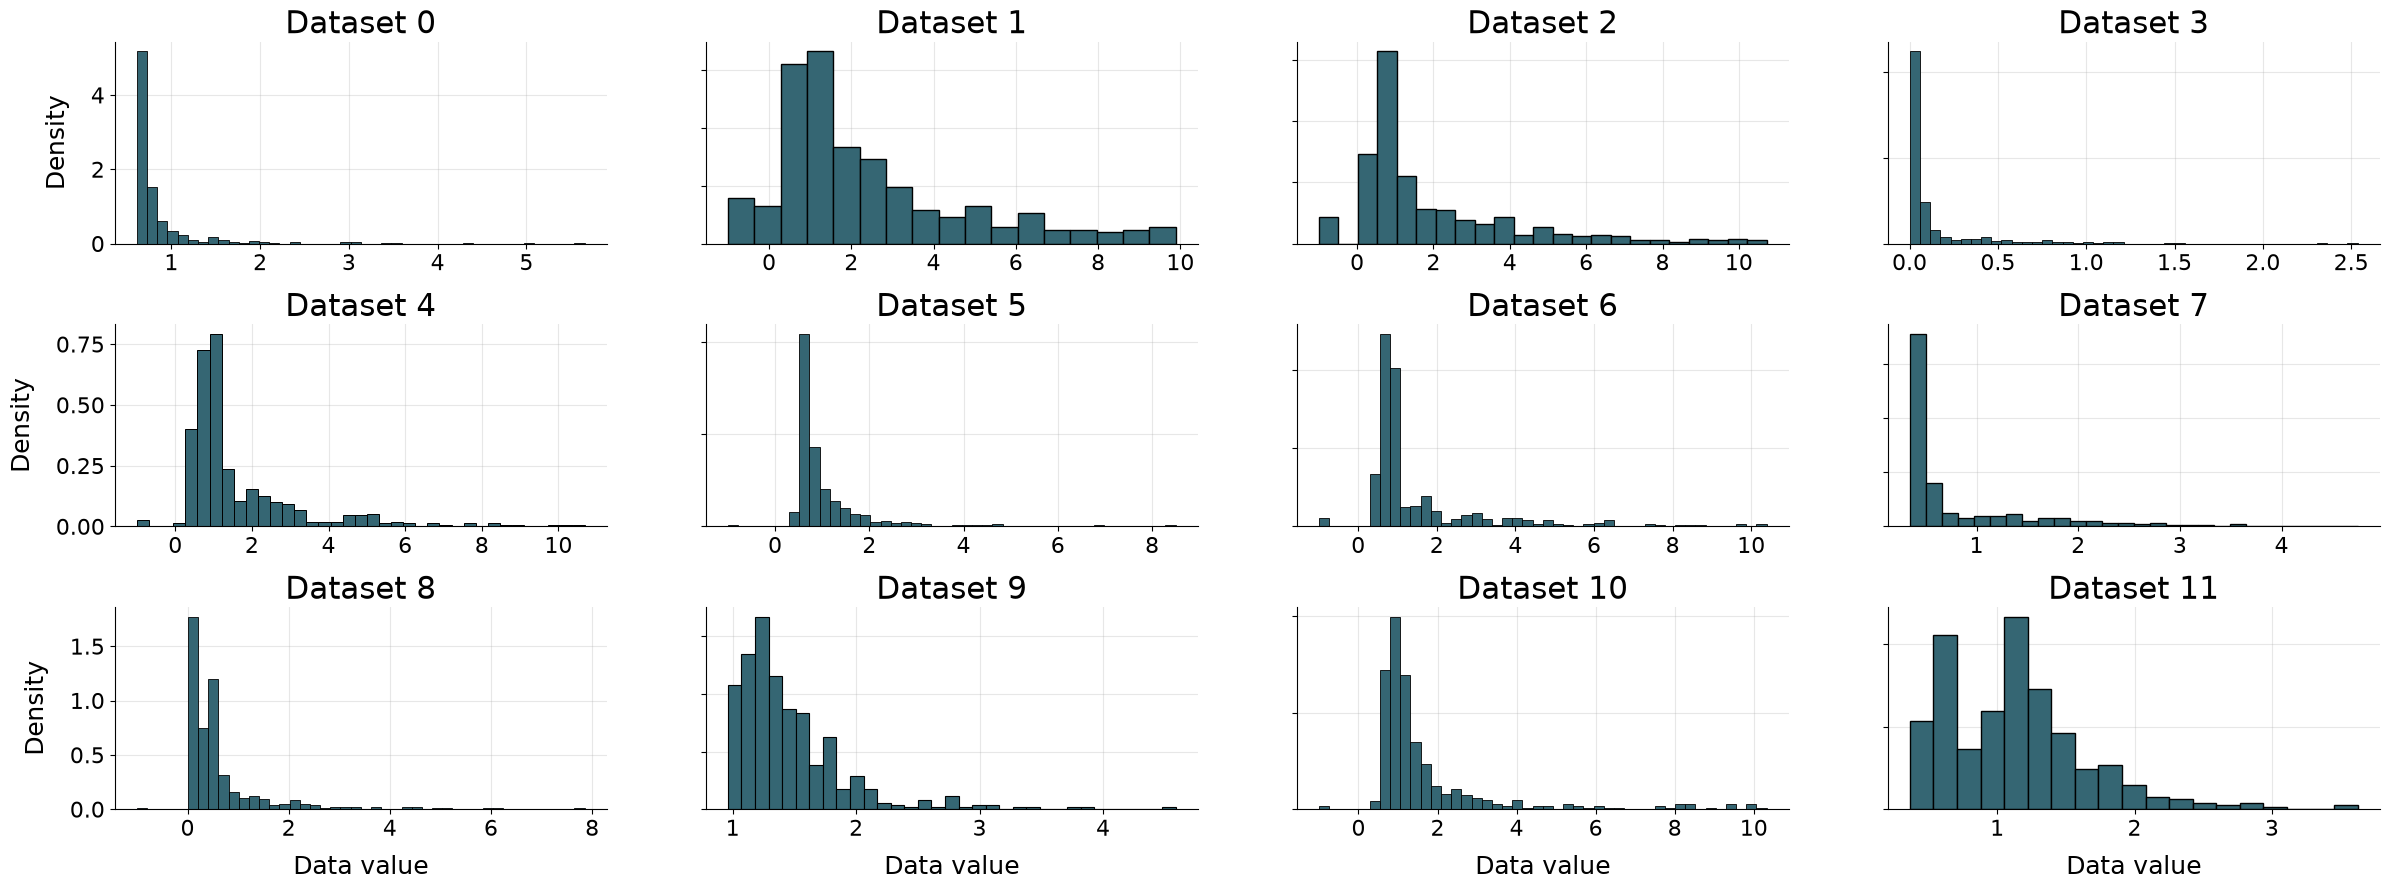

In [10]:
fig = model.plot_push_forward(
    batch_size=12,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist"
)

## Approximator Training

In [ ]:
workflow = sup.Workflow(
    model=model,
    approximator="marginal",
    mode="smoothing",
    checkpoint_filepath="checkpoints/ms_study_ddm_regressors_v02"
)

In [ ]:
# train_data = model.sample(
#     batch_size=30_000,
#     num_steps=NUM_STEPS
# )

# val_data = model.sample(
#     batch_size=200,
#     num_steps=NUM_STEPS
# )

In [ ]:
# history = workflow.fit_offline(
#     data=train_data,
#     validation_data=val_data,
#     epochs=50,
#     batch_size=32
# )

In [ ]:
history = workflow.fit_online(
    num_steps=NUM_STEPS,
    epochs=100,
    num_batches_per_epoch=1000,
    batch_size=32
)

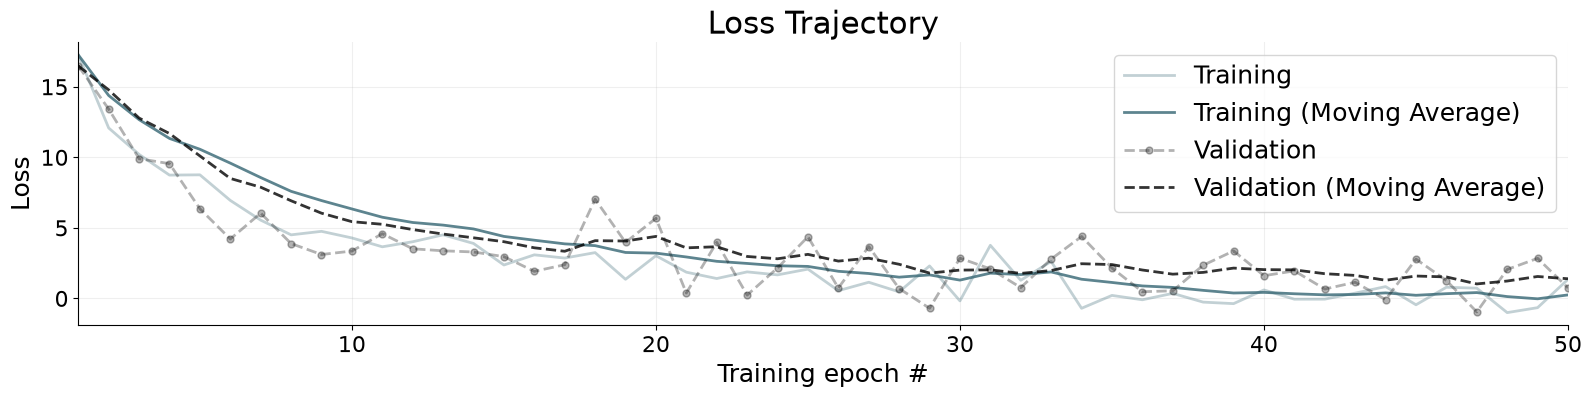

In [12]:
fig = workflow.plot_history(workflow.history)

## Model Verification

In [13]:
targets = model.sample(batch_size=200, num_steps=NUM_STEPS)

In [14]:
samples = workflow.sample(data=targets, num_samples=500, batch_size=5)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

/Users/lschumacher/Documents/GitHub/superstats/.venv/lib/python3.13/site-packages/keras/src/ops/nn.py:959: UserWarning: You are using a softmax over axis 3 of a tensor of shape (2500, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

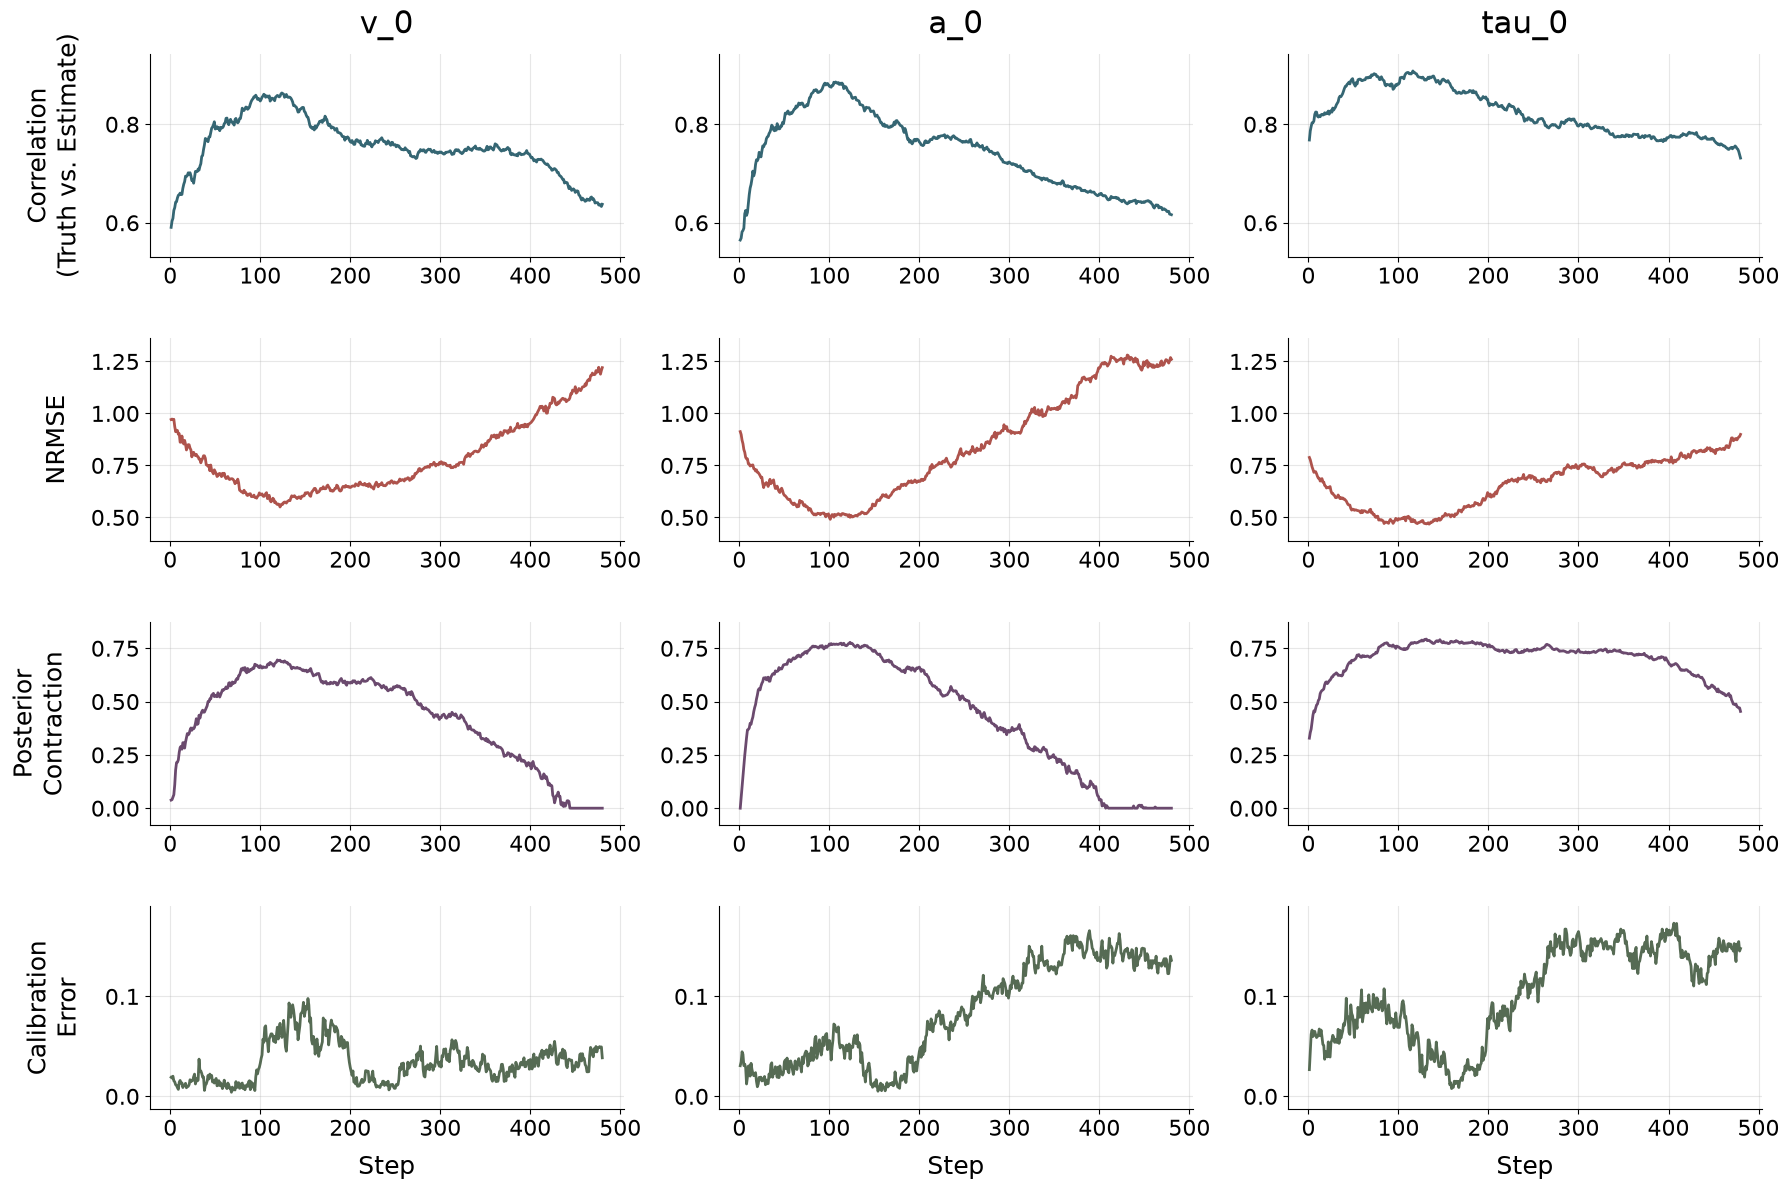

In [15]:
fig = workflow.verify_time_varying(targets=targets, estimates=samples)

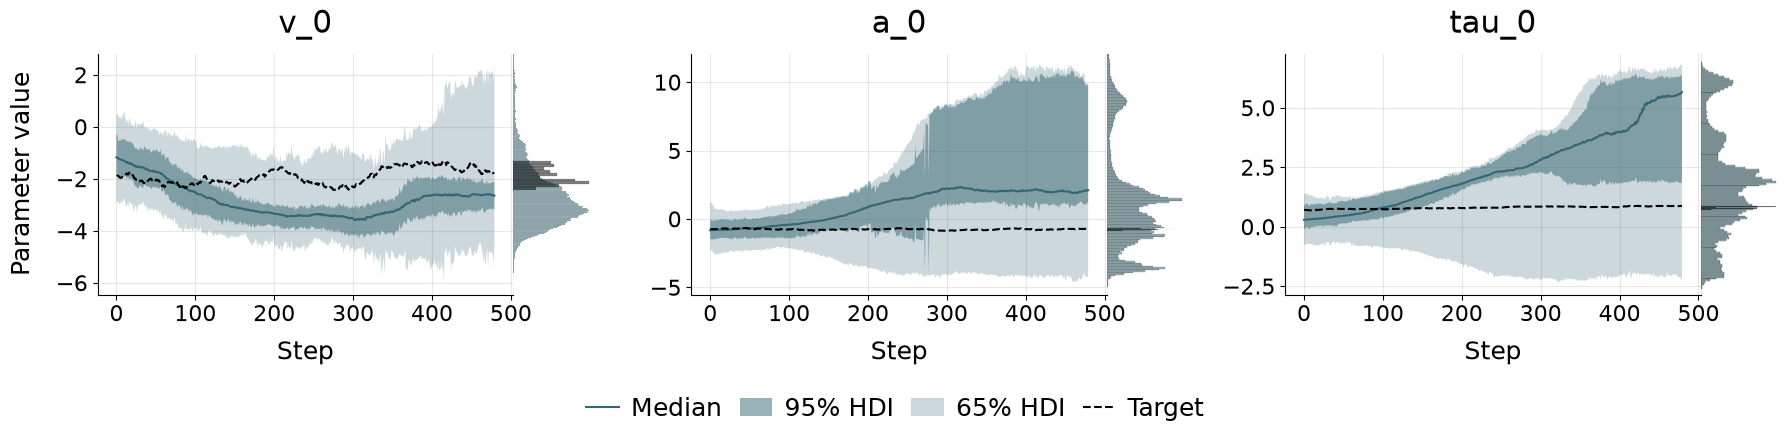

In [23]:
fig = workflow.plot_time_varying_posterior(
    estimates=samples,
    targets=targets,
    data_idx=3
)

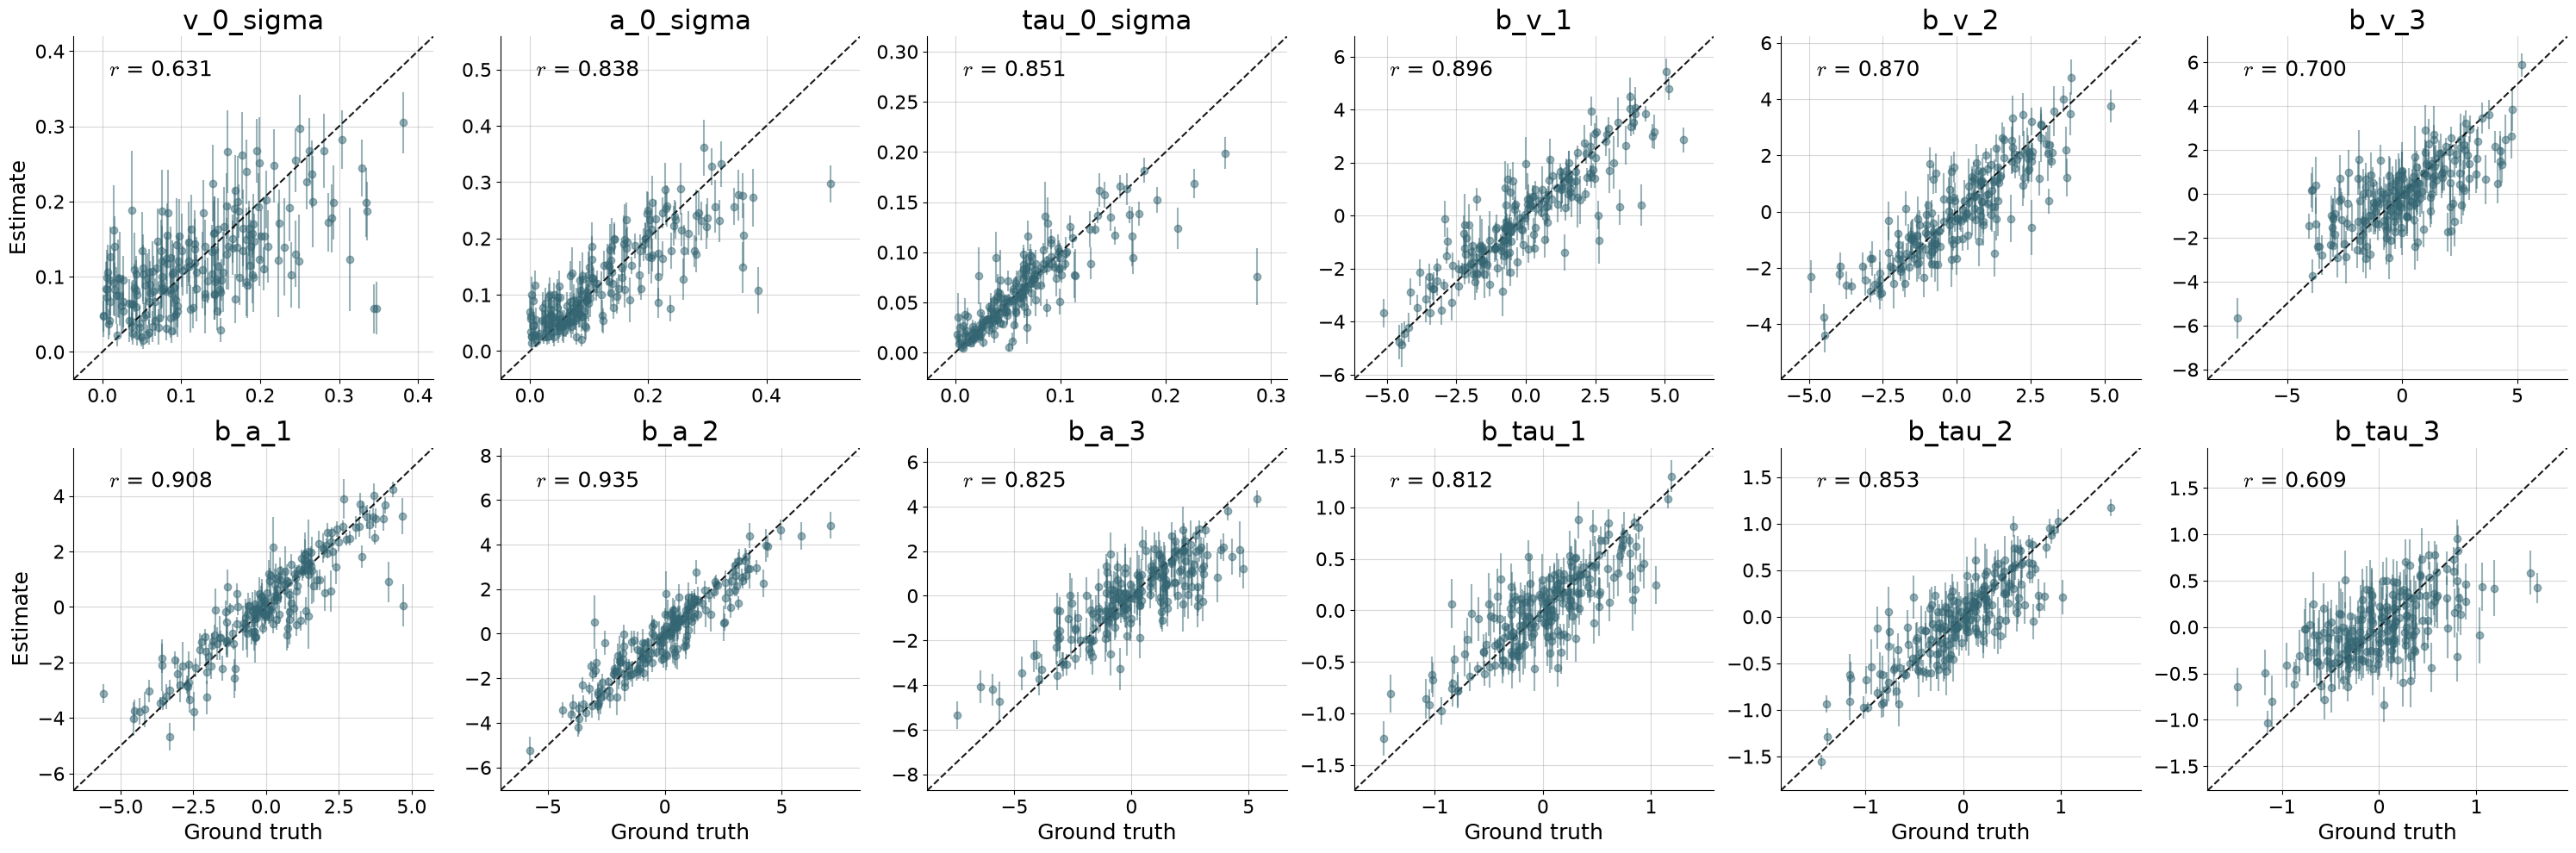

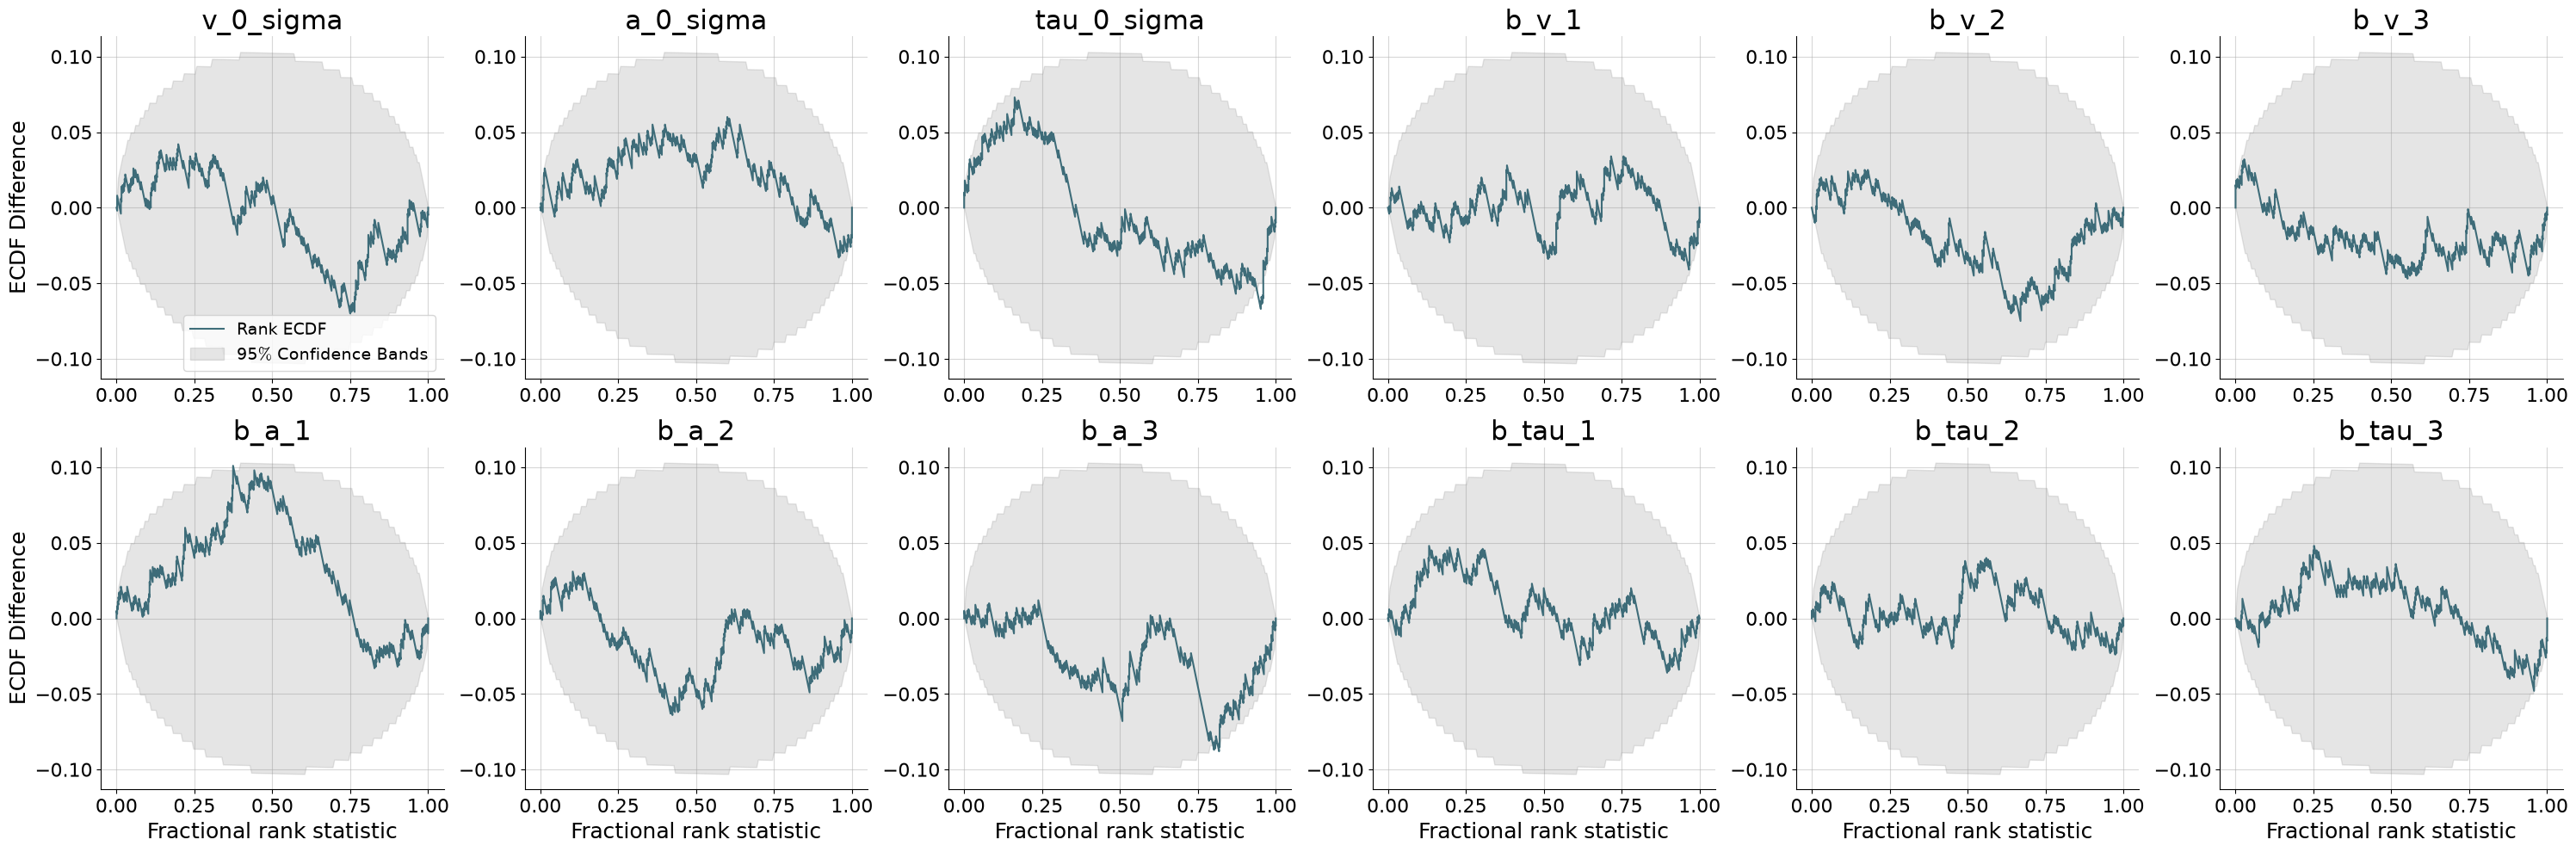

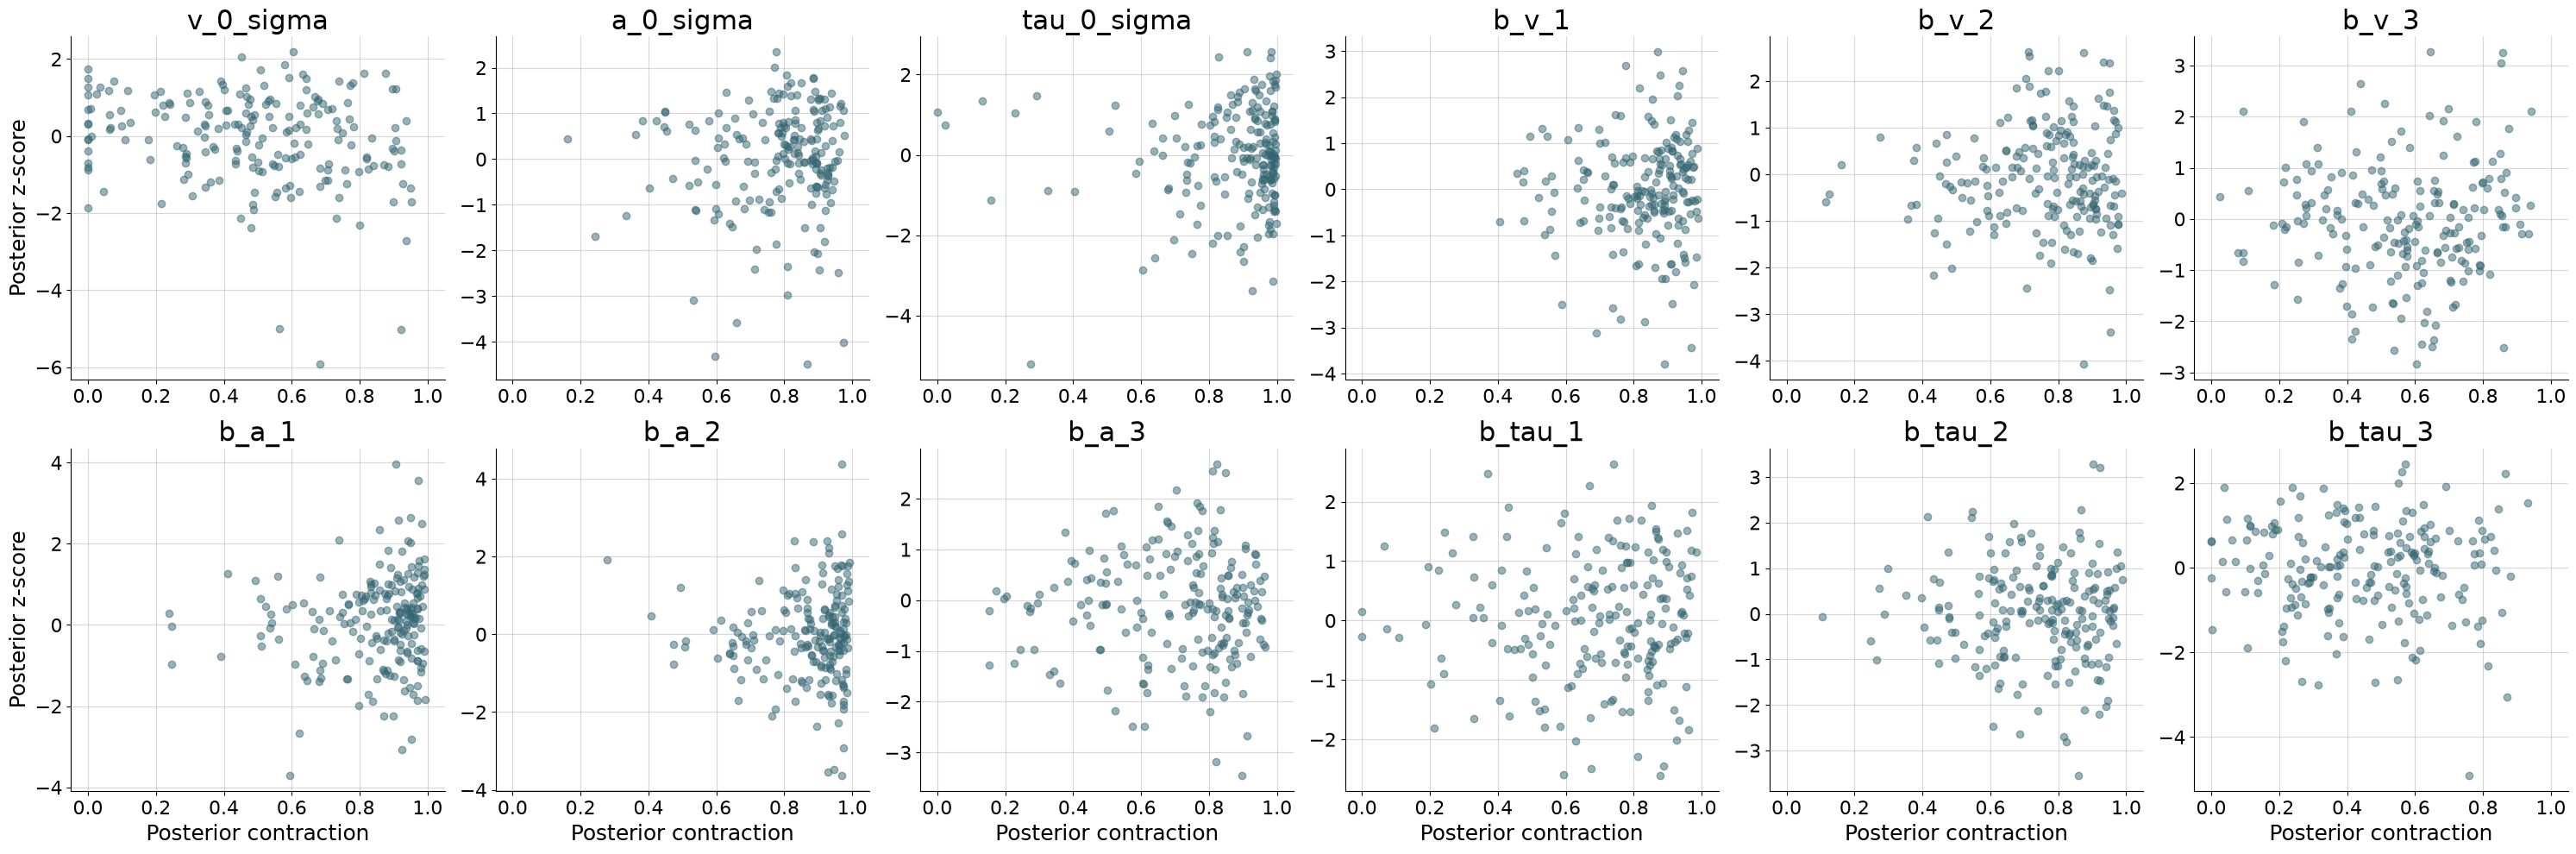

In [16]:
from scipy.stats import median_abs_deviation


fig_recovery, fig_calibration, fig_z_score_contraction = workflow.verify_time_invariant(
    estimates=samples,
    targets=targets,
    uncertainty_agg=median_abs_deviation
)

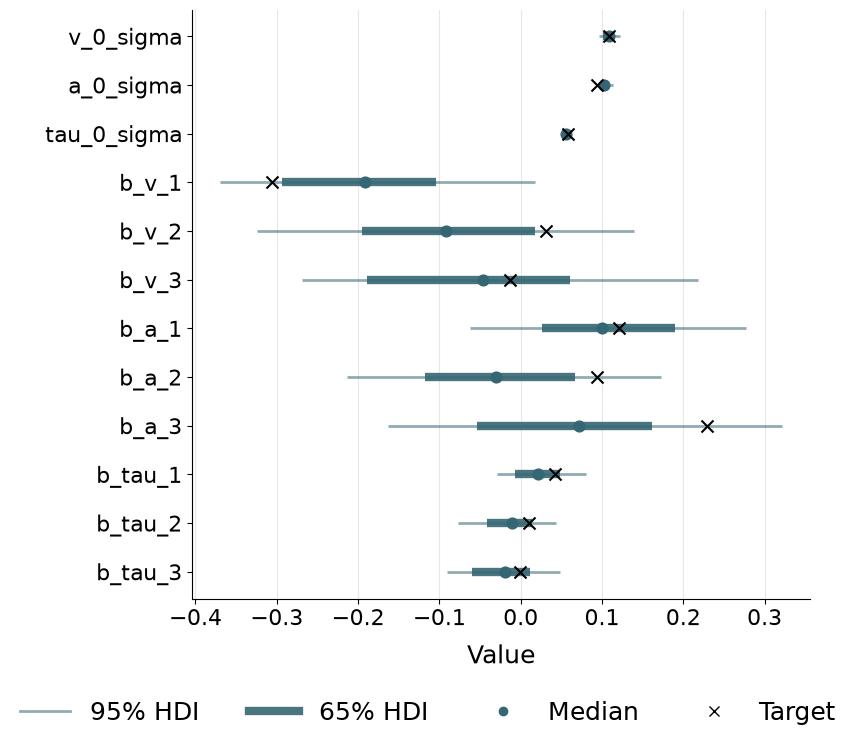

In [21]:
fig = workflow.plot_forest(
    estimates=samples,
    targets=targets,
    aggregation=np.median
)